installing necessary libraries

In [31]:
!pip install pillow

In [32]:
!pip install opencv-python

In [33]:
!sudo apt install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [34]:
!pip install pytesseract

Importing the libraries

In [35]:
import cv2
from PIL import Image
import pytesseract

using pillow library to do some tasks like opening an image, rotating it and saving it to another path

In [36]:
img_path= '/media/O.jpg'
img= Image.open(img_path)
print(img.size)
img.rotate(90).save('/ocr_rotated.jpg')

(1200, 1600)


using opencv library to perform some other tasks

In [37]:
#opening an image

image_path='/media/new_ocr.jpg'
image= cv2.imread(image_path)

In [38]:
import matplotlib.pyplot as plt
#displaying the image
def display(img_path):

  #dpi means dots per inch aka how many pixels
  dpi= 80
  img_data= plt.imread(img_path)
  height, width, depth= img_data.shape

  #figure size in inches
  figsize= width / float(dpi), height / float(dpi)

  fig= plt.figure(figsize= figsize)

  #the axe of the figure
  ax= fig.add_axes([0,0,1,1])

  ax.axis('off')

  ax.imshow(img_data, cmap='gray')
  plt.show()


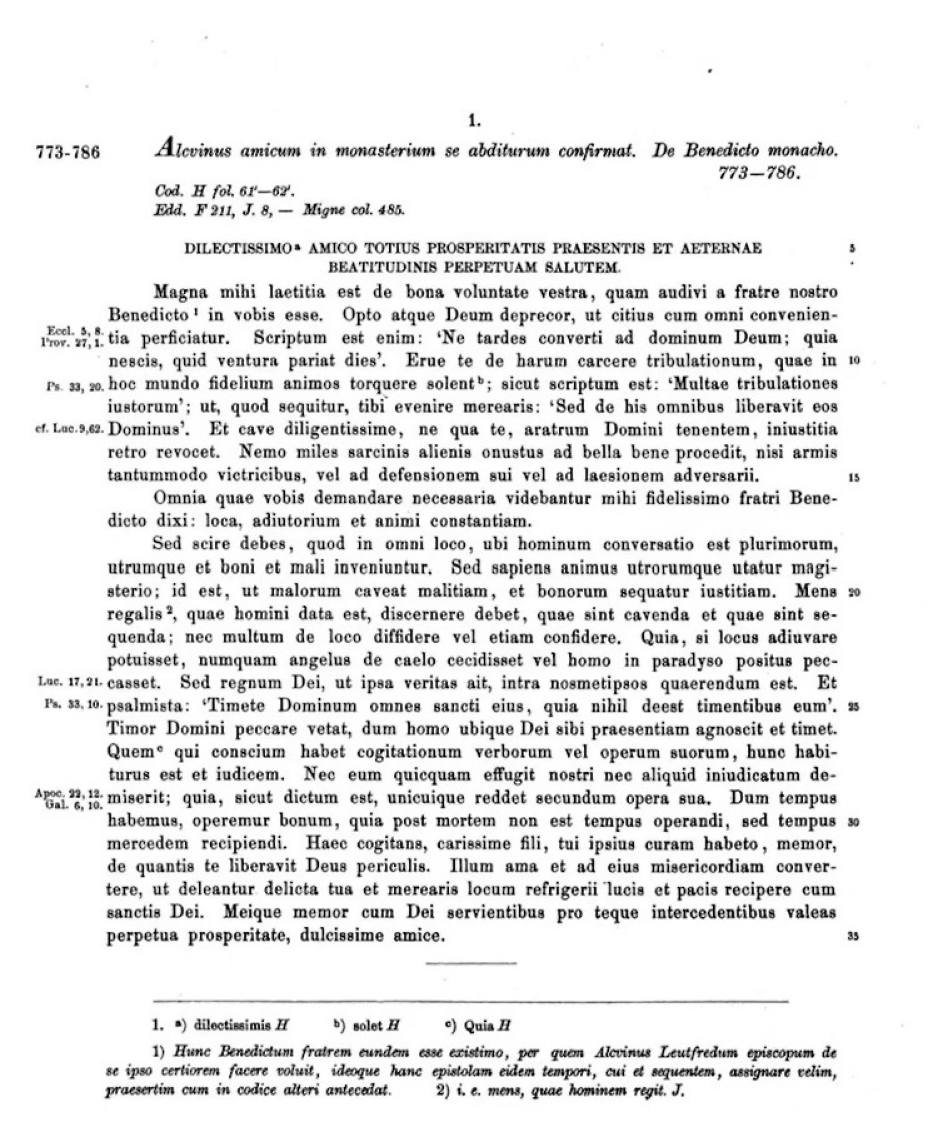

In [39]:
#displaying an image

display(image_path)

In [40]:
#inverting an image aka making the black white and the white black

inv_image= cv2.bitwise_not(image)
cv2.imwrite('/media/inverted_img.jpg',inv_image)

#this is only usefull in tesseract versions under 4
#useless as we're usuing tesseract 4.1

True

In [41]:
#rescalling is difficult to do well



In [42]:
#Binarization aka converting an img to black and white only no other value in between
#pre-processing step that makes it easier to analyze shapes
#Computers find it much easier to analyze shapes when they are stripped of color and shading

#first we'll convert it to grayscale so it's easuer at first

def grayscale(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [43]:
img_gray=grayscale(image)
cv2.imwrite("/media/gray.jpg",img_gray)

True

In [44]:
#the actual binarization now
#we're making threshold if the pixel intensity is higher it turns white
#if it's lower it turns black

thresh, image_bw= cv2.threshold(img_gray,145,255,cv2.THRESH_BINARY)

#thresh return the threshold value used

cv2.imwrite("/media/bw.jpg",image_bw)


True

In [45]:
#noise removal

import numpy as np

def noise_removal(image):

  #a kernel is a small matrix that slides over your image to perform an operation
  kernel = np.ones((1,1), np.uint8)

  #dilation adds pixels to white objects
  #thickens the white part

  image = cv2.dilate(image, kernel, iterations=1)

  kernel = np.ones((1,1), np.uint8)

  #erosion eats away the white

  image = cv2.erode(image, kernel, iterations=1)

  #closing samll holes
  image = cv2.morphologyEx(image, cv2.MORPH_CLOSE,kernel)

  #blur with 3x3 area
  image = cv2.medianBlur(image, 3)
  return (image)

#try tesseract first without noise removal and if the results are off
#then we remove the noise otherwise it's uselss

In [46]:
no_noise= noise_removal(image_bw)
cv2.imwrite('/media/no_noise.jpg', no_noise)

True

In [47]:
#using dilation and erosion without morphology and blur
#when there's no noise but the font is either too thick or too thin

#works with inverted images
#thinning the font

def thin_font(image):
  image = cv2.bitwise_not(image)
  kernel = np.ones((3,3),np.uint8)
  image = cv2.erode(image, kernel, iterations=1)
  image = cv2.bitwise_not(image)
  return(image)

In [48]:
eroded_image= thin_font(image_bw)
cv2.imwrite('/media/eroded_image.jpg', eroded_image)

True

In [49]:
def thick_font(image):
  image = cv2.bitwise_not(image)
  kernel = np.ones((3,3),np.uint8)
  image = cv2.dilate(image, kernel, iterations=1)
  image = cv2.bitwise_not(image)
  return(image)

In [50]:
dilated_image= thick_font(no_noise)
cv2.imwrite('/media/dilated_image.jpg', dilated_image)

True

In [51]:
#getting the angle

def getSkewAngle(cvImage) -> float:
    # Prep image, copy, convert to gray scale, blur, and threshold
    newImage = cvImage.copy()
    #gray = cv2.cvtColor(newImage, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(newImage, (9, 9), 0)
    thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 5))
    dilate = cv2.dilate(thresh, kernel, iterations=10)

    contours, hierarchy= cv2.findContours(dilate, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key = cv2.contourArea, reverse = True)
    for c in contours:
      rect = cv2.boundingRect(c)
      x,y,w,h = rect
      cv2.rectangle(newImage,(x,y),(x+w,y+h),(0,255,0),2)

    largestContour= contours[0]
    print(len(contours))
    minAreaRect = cv2.minAreaRect(largestContour)
    cv2.imwrite('mesia/boxes.jpg',newImage)

    angle = minAreaRect[-1]
    if angle < -45:
      angle = 90 + angle
    return -1.0 * angle

In [52]:
#rotation

def rotateImage(cvImage, angle:float):
  newImage= cvImage.copy()
  (h, w) = newImage.shape[:2]
  center= (w // 2, h // 2)
  M = cv2.getRotationMatrix2D(center, angle, 1.0)
  newImage= cv2.warpAffine(newImage, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
  return newImage

In [53]:
#very important as this is the actual deskewing

def deskew(cvImage):
  angle = getSkewAngle(cvImage)
  return rotateImage(cvImage, -1.0 * angle)

In [54]:
deskewed_image= deskew(dilated_image)
cv2.imwrite('/media/deskewed_image.jpg', deskewed_image)

2


True

In [55]:
#removing the most of the borders

def remove_borders(image):
  contours, hierarchy = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  cntSorted = sorted(contours, key=lambda x:cv2.contourArea(x))
  cnt = cntSorted[-1]
  x, y, w, h = cv2.boundingRect(cnt)
  crop = image[y:y+h, x:x+w]
  return (crop)

In [56]:
no_borders= remove_borders(deskewed_image)
cv2.imwrite('/media/no_borders.jpg',no_borders)

True

In [57]:
#adding borders if there's text all the way up against the borders
#the models were trained with some borders

color = [255, 255, 255]
top, bottom, left, right = [150]*4

In [58]:
image_with_border = cv2.copyMakeBorder(no_borders, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
cv2.imwrite('/media/borders.jpg',image_with_border)

True

In [59]:
#testing the actual pytesseract with the raw img

ocr_img= pytesseract.image_to_string(img)
print(ocr_img)

her two-tenths were rural but
and at rapidly growing segment of
the es, most of which lives in the frinpe Pula 4 rural
popl™the metropolitan areas along the main high extending out
fre ial ond SO/Suficing Areas “Thee Nees a
‘over after the major type-of-; reas which
ae! tell od by one or two agricultaral cating Ste3s which are
a the easter areas as indicated by fig. x, corn, wheat nested.
Jn to a lesser extent soybeans, tobacco, fruit an » Oats, hay
snd (0 8s ruch of the roughe;
beef cattle and poultry

r land is kept im ruck crops are
with some scattered dairy cattle an

did not farm. Th thi,
the population js ges Ste

in pasture
are found on the Talorigneniy
id sheep. Livestock,

ee cutter, Ozark and
Quast jons shows numerous small general fi See
abet in wester Nevada, the lower Snake rings eas Uneet
ign on, central Utah, southeastern Idaho, western Me a

Arkansas valley, the San Luis valley and Sen Joona
ae a do and northwestern New Mexico and the Yakine, valley
Nebraska and Senten


In [60]:
#testing with the modified img
img_des=Image.open('/media/deskewed_image.jpg')
ocr_des= pytesseract.image_to_string(img_des)
print(ocr_des)

71186 Alerans cancon re wonesiram s¢ abiderven conjirant De Beardecto monsthe
773-786.
tod Master oe
Ba Fondo yee ons

DLEeTRMINye 40 a TOTS MRAEYRITATO PRAESENTIO ET ALTIANAR .
DAATITVTANGS CAEPETL AM SALTON

 

tantetminnde wetembas. ve: od defense eu vei ad larwwern adterearn ”
imme queer voles demardare precovens “lebenter mils Siehreces fate: Buse:
dere ear Seen edeeten ar ef apes censlantene
ed orae doheo. qed mone lane, ot. Roeweesy contereats rel planmerans,
Rarengee ct bees vt Ora acer Ned vaperns ey-mran etrccengee wlater meg:
term, diem, ul macrem cowal madtam. of beneres eequaier webtiom. Mena
egal o". que beoun: date cot. drocersere Gebel. quer carends et quae unl ce:
qureta mee maltan de loc diffidere ve: ri.om cunfidere. Ques. 0: locus ehavars
Padeecl, Bemqwem aagetze de rarin rondnert tel heme .2 parelyes poompe prt-
amet) Ned ergiam De: nf yes veretes 2,1, intra wermrhpoos yoorrendam wet Et
Fem gaglemts “Tomele Dutees omere antl rics. qua mb! devel tmenthes rem’ @
Tarc